In [1]:
from udenoise import RawImageDataset
from pathlib import Path
import torch

In [7]:
dataset = RawImageDataset(Path("../data/processed"))

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def show_packed_bayer(patch, figsize=(6, 6)):
    patch = patch.cpu()
    if isinstance(patch, torch.Tensor):
        patch = patch.numpy()
    
    _, h, w = patch.shape
    R, G1, G2, B = patch[0], patch[1], patch[2], patch[3]
    
    # Average the two green channels
    G = (G1 + G2) / 2.0
    
    # Stack into RGB — each channel is (H, W) at half resolution
    rgb = np.stack([R, G, B], axis=-1)  # (H, W, 3)
    
    # Gamma correct for display (linear → sRGB approximation)
    rgb = np.clip(rgb, 0, 1)
    rgb = rgb ** (1/2.2)
    
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()

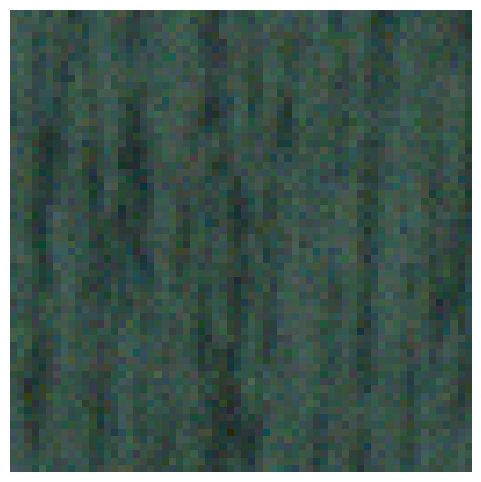

In [12]:
show_packed_bayer(dataset[5377][0])

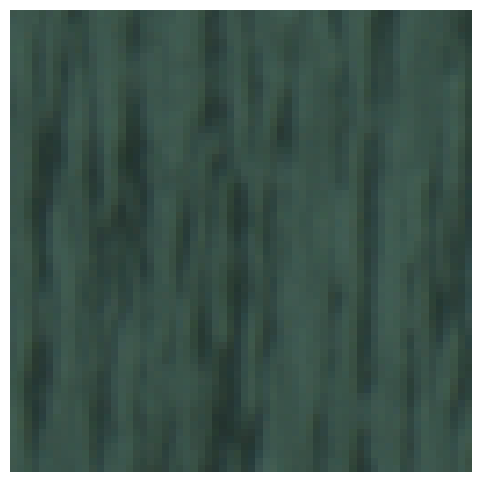

In [13]:
show_packed_bayer(dataset[5377][1])